In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/paprikaryash/dataset/Data_Science_Challenge.csv


In [3]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/paprikaryash/dataset/Data_Science_Challenge.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4)

# paste the path from Cell 1
DATA = "/kaggle/input/datasets/paprikaryash/dataset/Data_Science_Challenge.csv"

df = pd.read_csv(DATA)
df.columns = df.columns.str.strip().str.lower()
print(df.shape)
print(df.columns.tolist())
df.head()

(3333, 21)
['state', 'account length', 'area code', 'phone number', 'international plan', 'voice mail plan', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls', 'churn']


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
# Cell 3 — cleanliness


print(df.info())
print("nulls:\n", df.isna().sum())
print("unique phones:", df["phone number"].nunique())
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [7]:
# Cell 4 — first insights


print(df.groupby("international plan")["churn"].mean())
print(df.groupby("voice mail plan")["churn"].mean())
print(df.groupby("customer service calls")["churn"].agg(["mean", "count"]))
print("day minutes vs charge:",
      df[["total day minutes", "total day charge"]].corr().iloc[0, 1])

international plan
no     0.114950
yes    0.424149
Name: churn, dtype: float64
voice mail plan
no     0.167151
yes    0.086768
Name: churn, dtype: float64
                            mean  count
customer service calls                 
0                       0.131994    697
1                       0.103302   1181
2                       0.114625    759
3                       0.102564    429
4                       0.457831    166
5                       0.606061     66
6                       0.636364     22
7                       0.555556      9
8                       0.500000      2
9                       1.000000      2
day minutes vs charge: 0.9999999521904007


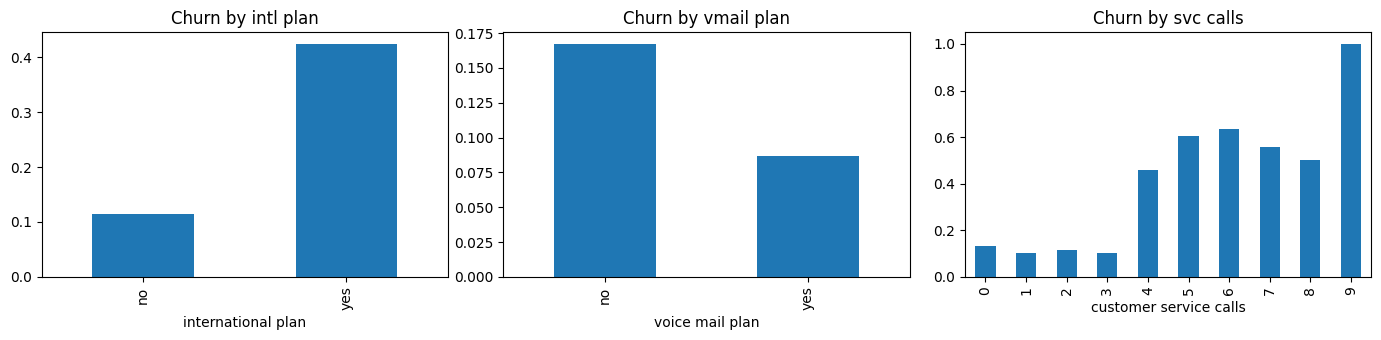

In [8]:
# Cell 5 — three EDA plots



fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
df.groupby("international plan")["churn"].mean().plot(kind="bar", ax=axes[0], title="Churn by intl plan")
df.groupby("voice mail plan")["churn"].mean().plot(kind="bar", ax=axes[1], title="Churn by vmail plan")

df.groupby("customer service calls")["churn"].mean().plot(kind="bar", ax=axes[2], title="Churn by svc calls")

plt.tight_layout()
plt.show()

## Cell 6 — drop ID, encode plans, dummy area code

In [9]:
work = df.drop(columns=["phone number", "state"]).copy()
work["international plan"] = work["international plan"].map({"yes": 1, "no": 0})
work["voice mail plan"] = work["voice mail plan"].map({"yes": 1, "no": 0})
work["churn"] = work["churn"].astype(int)

In [10]:
work = pd.get_dummies(work, columns=["area code"], prefix="area_code")

In [11]:
print(work.isna().sum().sum())
print(work["international plan"].value_counts())
print(work.head())

0
international plan
0    3010
1     323
Name: count, dtype: int64
   account length  international plan  voice mail plan  number vmail messages  \
0             128                   0                1                     25   
1             107                   0                1                     26   
2             137                   0                0                      0   
3              84                   1                0                      0   
4              75                   1                0                      0   

   total day minutes  total day calls  total day charge  total eve minutes  \
0              265.1              110             45.07              197.4   
1              161.6              123             27.47              195.5   
2              243.4              114             41.38              121.2   
3              299.4               71             50.90               61.9   
4              166.7              113             28.34 

In [12]:
# Cell 7 — X / y and 80/20 stratified split


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
y = work["churn"]
X = work.drop(columns=["churn"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_s = scaler.transform(X_test)
print("train", X_train.shape, "churn rate", y_train.mean())
print("test ", X_test.shape, "churn rate", y_test.mean())

train (2666, 20) churn rate 0.1447861965491373
test  (667, 20) churn rate 0.1454272863568216


Cell 8 — three models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [15]:
pos = y_train.sum()
neg = len(y_train) - pos

In [16]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")

In [17]:
rf = RandomForestClassifier(
    n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1
)

In [18]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.08,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

In [19]:
lr.fit(X_train_s, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [20]:
rf.fit(X_train, y_train)     # trees do not need scaling

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [21]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [23]:
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, f1_score
)

In [24]:
def show(name, model, Xt):
    proba = model.predict_proba(Xt)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print("=" * 50, name)
    print(classification_report(y_test, pred, digits=3))
    print("ROC-AUC", roc_auc_score(y_test, proba))
    print("PR-AUC ", average_precision_score(y_test, proba))
    print("F1     ", f1_score(y_test, pred))
    print(confusion_matrix(y_test, pred))

In [25]:
show("LogReg", lr, X_test_s)
show("RF", rf, X_test)
show("XGB", xgb, X_test)

================================================== LogReg
              precision    recall  f1-score   support

           0      0.944     0.765     0.845       570
           1      0.346     0.732     0.470        97

    accuracy                          0.760       667
   macro avg      0.645     0.748     0.658       667
weighted avg      0.857     0.760     0.790       667

ROC-AUC 0.8153373123530476
PR-AUC  0.4191835936110018
F1      0.47019867549668876
[[436 134]
 [ 26  71]]
================================================== RF
              precision    recall  f1-score   support

           0      0.934     0.988     0.960       570
           1      0.891     0.588     0.708        97

    accuracy                          0.930       667
   macro avg      0.912     0.788     0.834       667
weighted avg      0.927     0.930     0.923       667

ROC-AUC 0.8912099837221922
PR-AUC  0.7893109776584072
F1      0.7080745341614907
[[563   7]
 [ 40  57]]
=========================

In [26]:
# Cell 10 — ROC and Precision-Recall


from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [28]:
p_lr = lr.predict_proba(X_test_s)[:, 1]
p_rf = rf.predict_proba(X_test)[:, 1]
p_xgb = xgb.predict_proba(X_test)[:, 1]

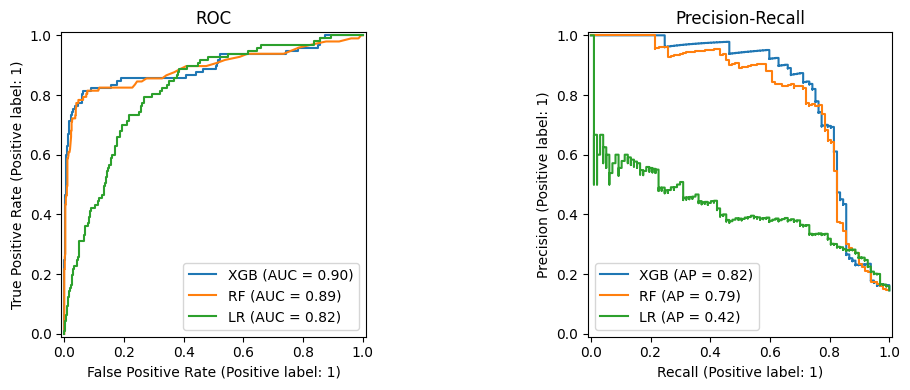

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, p_xgb, ax=ax[0], name="XGB")
RocCurveDisplay.from_predictions(y_test, p_rf, ax=ax[0], name="RF")
RocCurveDisplay.from_predictions(y_test, p_lr, ax=ax[0], name="LR")
PrecisionRecallDisplay.from_predictions(y_test, p_xgb, ax=ax[1], name="XGB")
PrecisionRecallDisplay.from_predictions(y_test, p_rf, ax=ax[1], name="RF")
PrecisionRecallDisplay.from_predictions(y_test, p_lr, ax=ax[1], name="LR")
ax[0].set_title("ROC")
ax[1].set_title("Precision-Recall")
plt.tight_layout()
plt.show()

In [ ]:
# PR curve matters more than ROC here (~15% churn).



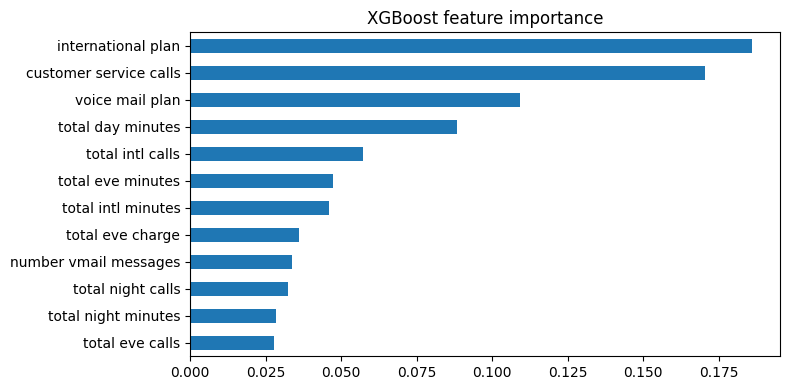

In [30]:
# Cell 11 — why the model thinks people leave


imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()
imp.tail(12).plot(kind="barh", title="XGBoost feature importance")
plt.tight_layout()
plt.show()

In [31]:
# Cell 12 — written answers (this is what SS/Spotify grade)


print("""
EDA
- 3333 customers, 0 missing, unique phone numbers → drop phone number (ID).
- Drop state (51 levels) to avoid a huge sparse one-hot.
- Churn rate ~14.5% (483 / 3333) → accuracy is a bad headline metric.
- International plan = yes → much higher churn.
- Customer service calls >= 4 → churn jumps.
- Day/eve/night/intl minutes are almost equal to their charge columns (collinear).
- Voicemail plan is slightly protective.

SPLIT
- 80/20 so the test set still has ~100 churners.
- stratify=y keeps the 14.5% rate in both sets.
- No timestamp, so a random split is valid.
- StandardScaler fit on train only (no leakage).

MODEL
- LogReg = readable baseline with class_weight='balanced'.
- RF / XGB capture non-linear effects (svc calls x intl plan).
- Pick XGB if it wins PR-AUC and class-1 F1/recall (usual on this table).
- A small neural net is optional; on 3.3k rows trees usually beat it.

METRICS
- Report recall (missed churners), precision (wasted offers),
  F1, ROC-AUC, PR-AUC, confusion matrix.
- Do not lead with accuracy (~85% by predicting nobody churns).
- Threshold 0.5 is a default; in production set it from offer cost vs lost LTV.

PRODUCTION
- Data drift: input mix changes (more intl plans, different call volumes).
- Concept drift: what 'churn' means or why people leave changes.
- Define the label as 'will leave in the next 30 days', not a snapshot flag.
- Monitor predicted vs actual churn rate; retrain on a schedule.
- Never score phone number.
- If high-risk customers get discounts, later labels are biased — log treatments.
""")


EDA
- 3333 customers, 0 missing, unique phone numbers → drop phone number (ID).
- Drop state (51 levels) to avoid a huge sparse one-hot.
- Churn rate ~14.5% (483 / 3333) → accuracy is a bad headline metric.
- International plan = yes → much higher churn.
- Customer service calls >= 4 → churn jumps.
- Day/eve/night/intl minutes are almost equal to their charge columns (collinear).
- Voicemail plan is slightly protective.

SPLIT
- 80/20 so the test set still has ~100 churners.
- stratify=y keeps the 14.5% rate in both sets.
- No timestamp, so a random split is valid.
- StandardScaler fit on train only (no leakage).

MODEL
- LogReg = readable baseline with class_weight='balanced'.
- RF / XGB capture non-linear effects (svc calls x intl plan).
- Pick XGB if it wins PR-AUC and class-1 F1/recall (usual on this table).
- A small neural net is optional; on 3.3k rows trees usually beat it.

METRICS
- Report recall (missed churners), precision (wasted offers),
  F1, ROC-AUC, PR-AUC, confusion m